<a href="https://colab.research.google.com/github/srirammulukuntla11/AIEC/blob/main/aiec_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ADALINE-BASED IRIS CLASSIFICATION SYSTEM

Dataset Shape: (150, 4)

Features:
- sepal length (cm)
- sepal width (cm)
- petal length (cm)
- petal width (cm)

Classes:
0 : setosa
1 : versicolor
2 : virginica

First 5 Samples:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  

TRAINING ADALINE

Training ADALINE for class: setosa

Training ADALINE for class: versicolor

Training ADALINE for class: virginica

Training completed successfully.

CLASSIFICATION RESULTS

Accuracy: 73.33%

Classification Repor

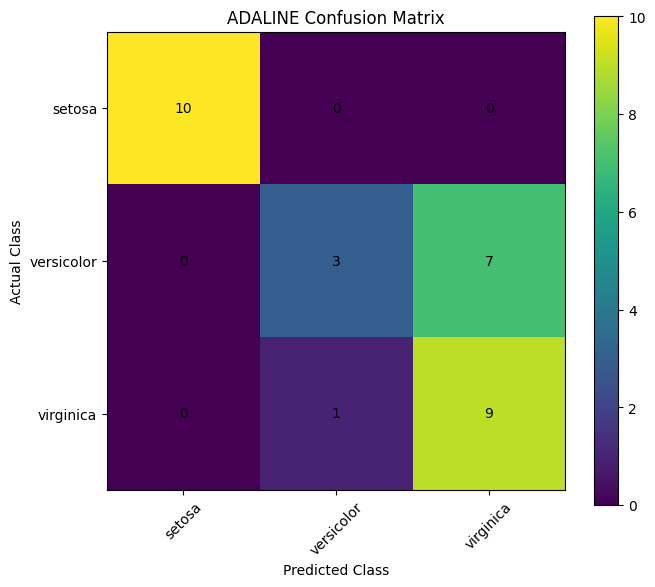

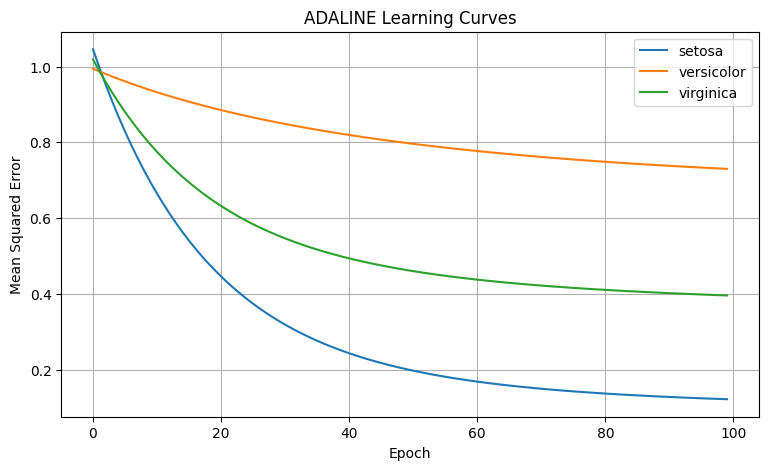


ADAPTIVE LEARNING RATE EXPERIMENT

Training ADALINE for class: setosa

Training ADALINE for class: versicolor

Training ADALINE for class: virginica

Training ADALINE for class: setosa

Training ADALINE for class: versicolor

Training ADALINE for class: virginica

Training ADALINE for class: setosa

Training ADALINE for class: versicolor

Training ADALINE for class: virginica
 Learning Rate  Accuracy (%)
         0.001     76.666667
         0.010     73.333333
         0.050     76.666667

Best Learning Rate: 0.001
Best Accuracy: 76.67%

SAMPLE PREDICTIONS

Sample 1
Actual    : setosa
Predicted : setosa

Sample 2
Actual    : virginica
Predicted : virginica

Sample 3
Actual    : versicolor
Predicted : versicolor

Sample 4
Actual    : versicolor
Predicted : versicolor

Sample 5
Actual    : setosa
Predicted : setosa

CUSTOM IRIS PREDICTION

You can test a new Iris flower by calling:

predict_iris(
    sepal_length,
    sepal_width,
    petal_length,
    petal_width
)

Example:


predict

In [1]:
# ============================================================
# ADALINE-Based Adaptive Pattern Classification and Prediction
# System using the Iris Dataset
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# ============================================================
# 1. LOAD IRIS DATASET
# ============================================================

iris = load_iris()

X = iris.data
y = iris.target

feature_names = iris.feature_names
class_names = iris.target_names

print("=" * 70)
print("ADALINE-BASED IRIS CLASSIFICATION SYSTEM")
print("=" * 70)

print("\nDataset Shape:", X.shape)

print("\nFeatures:")
for feature in feature_names:
    print("-", feature)

print("\nClasses:")
for i, name in enumerate(class_names):
    print(i, ":", name)


# ============================================================
# 2. DATAFRAME
# ============================================================

df = pd.DataFrame(
    X,
    columns=feature_names
)

df["target"] = y

print("\nFirst 5 Samples:")
print(df.head())


# ============================================================
# 3. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# ============================================================
# 4. FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# ============================================================
# 5. ADALINE CLASS
# ============================================================

class ADALINE:

    def __init__(
        self,
        learning_rate=0.01,
        epochs=100,
        random_state=42
    ):

        self.learning_rate = learning_rate
        self.epochs = epochs
        self.random_state = random_state

        self.weights = None
        self.bias = None

        self.loss_history = []


    # --------------------------------------------------------
    # Initialize weights
    # --------------------------------------------------------

    def initialize(self, n_features):

        rng = np.random.RandomState(
            self.random_state
        )

        self.weights = rng.normal(
            loc=0.0,
            scale=0.01,
            size=n_features
        )

        self.bias = 0.0


    # --------------------------------------------------------
    # Linear activation
    # --------------------------------------------------------

    def net_input(self, X):

        return np.dot(
            X,
            self.weights
        ) + self.bias


    # --------------------------------------------------------
    # Train ADALINE using LMS / Delta Rule
    # --------------------------------------------------------

    def fit(self, X, y):

        self.initialize(
            X.shape[1]
        )

        n_samples = X.shape[0]

        self.loss_history = []

        for epoch in range(self.epochs):

            # Linear output
            output = self.net_input(X)

            # Error
            errors = y - output

            # Mean Squared Error
            mse = np.mean(
                errors ** 2
            )

            self.loss_history.append(
                mse
            )

            # Weight update
            self.weights += (
                self.learning_rate
                * (X.T @ errors)
                / n_samples
            )

            # Bias update
            self.bias += (
                self.learning_rate
                * np.mean(errors)
            )

        return self


    # --------------------------------------------------------
    # Predict continuous output
    # --------------------------------------------------------

    def predict_continuous(self, X):

        return self.net_input(X)


# ============================================================
# 6. MULTI-CLASS ADALINE
# ============================================================

class MultiClassADALINE:

    def __init__(
        self,
        learning_rate=0.01,
        epochs=100
    ):

        self.learning_rate = learning_rate
        self.epochs = epochs

        self.models = []


    # --------------------------------------------------------
    # Train one ADALINE per class
    # --------------------------------------------------------

    def fit(self, X, y):

        self.models = []

        n_classes = len(
            np.unique(y)
        )

        for class_id in range(n_classes):

            print(
                f"\nTraining ADALINE for class: "
                f"{class_names[class_id]}"
            )

            # One-vs-rest target
            binary_y = np.where(
                y == class_id,
                1,
                -1
            )

            model = ADALINE(
                learning_rate=self.learning_rate,
                epochs=self.epochs,
                random_state=42 + class_id
            )

            model.fit(
                X,
                binary_y
            )

            self.models.append(
                model
            )

        return self


    # --------------------------------------------------------
    # Calculate class scores
    # --------------------------------------------------------

    def decision_function(self, X):

        scores = []

        for model in self.models:

            output = model.predict_continuous(X)

            scores.append(output)

        return np.column_stack(
            scores
        )


    # --------------------------------------------------------
    # Predict class
    # --------------------------------------------------------

    def predict(self, X):

        scores = self.decision_function(X)

        return np.argmax(
            scores,
            axis=1
        )


# ============================================================
# 7. CREATE AND TRAIN ADALINE
# ============================================================

print("\n" + "=" * 70)
print("TRAINING ADALINE")
print("=" * 70)

adaline = MultiClassADALINE(
    learning_rate=0.01,
    epochs=100
)

adaline.fit(
    X_train,
    y_train
)

print("\nTraining completed successfully.")


# ============================================================
# 8. TEST PREDICTIONS
# ============================================================

y_pred = adaline.predict(
    X_test
)


# ============================================================
# 9. ACCURACY
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\n" + "=" * 70)
print("CLASSIFICATION RESULTS")
print("=" * 70)

print(
    f"\nAccuracy: {accuracy * 100:.2f}%"
)


# ============================================================
# 10. CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=class_names
    )
)


# ============================================================
# 11. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix:\n")

print(cm)


plt.figure(
    figsize=(7, 6)
)

plt.imshow(
    cm,
    interpolation="nearest"
)

plt.title(
    "ADALINE Confusion Matrix"
)

plt.colorbar()

plt.xticks(
    range(len(class_names)),
    class_names,
    rotation=45
)

plt.yticks(
    range(len(class_names)),
    class_names
)

plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "Actual Class"
)

for i in range(cm.shape[0]):

    for j in range(cm.shape[1]):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()


# ============================================================
# 12. LOSS CURVES
# ============================================================

plt.figure(
    figsize=(9, 5)
)

for i, model in enumerate(
    adaline.models
):

    plt.plot(
        model.loss_history,
        label=class_names[i]
    )

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Mean Squared Error"
)

plt.title(
    "ADALINE Learning Curves"
)

plt.legend()

plt.grid(True)

plt.show()


# ============================================================
# 13. ADAPTIVE LEARNING RATE EXPERIMENT
# ============================================================

print("\n" + "=" * 70)
print("ADAPTIVE LEARNING RATE EXPERIMENT")
print("=" * 70)

learning_rates = [
    0.001,
    0.01,
    0.05
]

adaptive_results = []

for lr in learning_rates:

    temp_model = MultiClassADALINE(
        learning_rate=lr,
        epochs=100
    )

    temp_model.fit(
        X_train,
        y_train
    )

    temp_pred = temp_model.predict(
        X_test
    )

    temp_accuracy = accuracy_score(
        y_test,
        temp_pred
    )

    adaptive_results.append({
        "Learning Rate": lr,
        "Accuracy (%)": temp_accuracy * 100
    })


adaptive_df = pd.DataFrame(
    adaptive_results
)

print(
    adaptive_df.to_string(
        index=False
    )
)


# ============================================================
# 14. BEST LEARNING RATE
# ============================================================

best_row = adaptive_df.loc[
    adaptive_df["Accuracy (%)"].idxmax()
]

print(
    f"\nBest Learning Rate: "
    f"{best_row['Learning Rate']}"
)

print(
    f"Best Accuracy: "
    f"{best_row['Accuracy (%)']:.2f}%"
)


# ============================================================
# 15. PREDICTION FUNCTION
# ============================================================

def predict_iris(
    sepal_length,
    sepal_width,
    petal_length,
    petal_width
):

    sample = np.array([
        [
            sepal_length,
            sepal_width,
            petal_length,
            petal_width
        ]
    ])

    # Scale using training scaler
    sample_scaled = scaler.transform(
        sample
    )

    # Prediction
    prediction = adaline.predict(
        sample_scaled
    )[0]

    # Scores
    scores = adaline.decision_function(
        sample_scaled
    )[0]

    predicted_class = class_names[
        prediction
    ]

    print("\n" + "=" * 50)
    print("IRIS PREDICTION")
    print("=" * 50)

    print(
        "\nInput Features:"
    )

    print(
        "Sepal Length:",
        sepal_length
    )

    print(
        "Sepal Width :",
        sepal_width
    )

    print(
        "Petal Length:",
        petal_length
    )

    print(
        "Petal Width :",
        petal_width
    )

    print(
        "\nPredicted Class:",
        predicted_class
    )

    print(
        "\nADALINE Scores:"
    )

    for i, score in enumerate(scores):

        print(
            f"{class_names[i]:15s}: "
            f"{score:.4f}"
        )

    return predicted_class


# ============================================================
# 16. SAMPLE PREDICTIONS
# ============================================================

print("\n" + "=" * 70)
print("SAMPLE PREDICTIONS")
print("=" * 70)

for i in range(5):

    prediction = adaline.predict(
        X_test[i].reshape(1, -1)
    )[0]

    print(
        f"\nSample {i + 1}"
    )

    print(
        "Actual    :",
        class_names[y_test[i]]
    )

    print(
        "Predicted :",
        class_names[prediction]
    )


# ============================================================
# 17. CUSTOM USER PREDICTION
# ============================================================

print("\n" + "=" * 70)
print("CUSTOM IRIS PREDICTION")
print("=" * 70)

print(
    """
You can test a new Iris flower by calling:

predict_iris(
    sepal_length,
    sepal_width,
    petal_length,
    petal_width
)

Example:
"""
)

print(
    """
predict_iris(
    5.1,
    3.5,
    1.4,
    0.2
)
"""
)

# Example prediction
predict_iris(
    5.1,
    3.5,
    1.4,
    0.2
)


# ============================================================
# 18. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("FINAL SUMMARY")
print("=" * 70)

print(
    f"""
Dataset              : Iris
Total Samples        : {len(X)}
Number of Features   : {X.shape[1]}
Number of Classes    : {len(class_names)}
Training Samples     : {len(X_train)}
Testing Samples      : {len(X_test)}
Best Learning Rate   : {best_row['Learning Rate']}
Best Accuracy        : {best_row['Accuracy (%)']:.2f}%
Algorithm            : ADALINE
Learning Rule        : LMS / Delta Rule
"""
)

print(
    "ADALINE classification completed successfully."
)